# ДЗ 4. Задание 8

In [1]:
from Bio import SeqIO
from Bio import motifs
from Bio.Seq import Seq
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

Вот это из задания 5:

In [2]:
records = SeqIO.parse("chr1.fna", "fasta")
record = next(records)
sequence_all = record.seq
sequence = sequence_all[10000:20000]

In [3]:
nucleotides = ['A', 'C', 'G', 'T']
counts = {i+j: 0 for i in nucleotides for j in nucleotides}

for i in range(len(sequence)-1):
    pair = sequence[i:i+2]
    if pair in counts:
        counts[pair] += 1
        
count_matrix = np.zeros((4, 4))

for i, n in enumerate(nucleotides):
    for j, m in enumerate(nucleotides):
        count_matrix[i, j] = counts[n + m]

In [4]:
P = count_matrix / count_matrix.sum(axis=1, keepdims=True)

df_P = pd.DataFrame(P, index=nucleotides, columns=nucleotides)
df_P

,A,C,G,T
A,0.191805,0.236936,0.418646,0.152613
C,0.270767,0.340256,0.092652,0.296326
G,0.198410,0.289861,0.339563,0.172167
T,0.104461,0.291361,0.411067,0.193111


Теперь текущее задание:

In [7]:
def generate_sequence(P, length, start):
    seq = [start]
    cur = nucleotides.index(start)
    
    for i in range(length - 1):
        cur = np.random.choice(len(nucleotides), p=P[cur])
        seq.append(nucleotides[cur])
    
    return ''.join(seq)

In [8]:
def compute_dinucleotide_freqs(seq):
    m = np.zeros((4, 4))
    for i in range(len(seq)-1):
        m[nucleotides.index(seq[i])][nucleotides.index(seq[i+1])] += 1
    
    s = m.sum(axis=1, keepdims=True)
    s[s == 0] = 1
    return m / s

In [10]:
n_sequences = 10
seq_length = 1000

all_freq_matrices = []

for i in range(n_sequences):
    seq = generate_sequence(P, seq_length, 'A')
    freq = compute_dinucleotide_freqs(seq)
    all_freq_matrices.append(freq)

Text(0.5, 1.0, 'Средняя по 10 последовательностям')

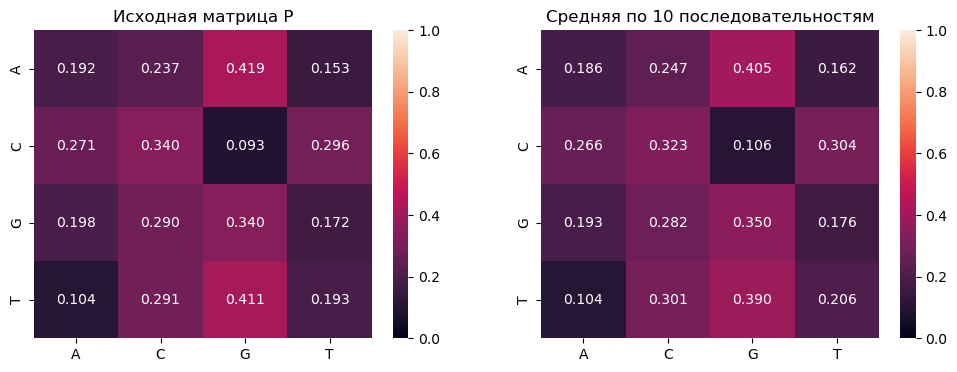

In [21]:
mean_freq = np.mean(all_freq_matrices, axis=0)


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.heatmap(P, annot=True, fmt='.3f', 
            xticklabels=nucleotides, yticklabels=nucleotides, vmin=0, vmax=1)
plt.title('Исходная матрица P')


plt.subplot(1, 2, 2)
sns.heatmap(mean_freq, annot=True, fmt='.3f',
            xticklabels=nucleotides, yticklabels=nucleotides, vmin=0, vmax=1)
plt.title('Средняя по 10 последовательностям')

In [17]:
diff = abs(P - mean_freq)
print(f"Максимальное отклонение: {diff.max():.4f}")
print(f"Среднее отклонение: {diff.mean():.4f}")

Максимальное отклонение: 0.0212
Среднее отклонение: 0.0095


Получившаяся средняя матрица визуально похожа на изначальную матрицу P, значит эмпирические данные подтверждают модель